# Entender los datos

Los clientes se van. Eso es un problema. Aquí hay 10,127 clientes en los datos y 1,627 de ellos decidieron irse.

El objetivo es entender qué hace que se vayan. Qué es diferente en su comportamiento. Eso que encontremos lo vamos a usar para entrenar un modelo que prediga a quién se va a ir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14,6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/BankChurners.csv').iloc[:, :-2]

## 1. Dimensión y estructura del dataset

In [ ]:
df.shape

(10127, 21)

10,127 registros es un buen tamaño. Tenemos 23 variables sobre cada cliente: datos personales, límites de crédito, cuánto gastan, cuánto se mueven, todo.

Es bastante información para trabajar.

## 2. Auditoría de calidad de datos

In [ ]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

No hay valores nulos. Los datos están completos. Eso está bien.

## 3. Detección de valores 'Unknown'

In [ ]:
def unknown_report(df):
    report = {}
    for col in df.select_dtypes(include='object').columns:
        count = (df[col]=='Unknown').sum()
        if count > 0:
            report[col] = count
    return pd.DataFrame(report.items(), columns=['Variable','Cantidad']).sort_values(by='Cantidad', ascending=False)

unknown_df = unknown_report(df)
unknown_df

,Variable,Cantidad
0,Education_Level,1519
2,Income_Category,1112
1,Marital_Status,749


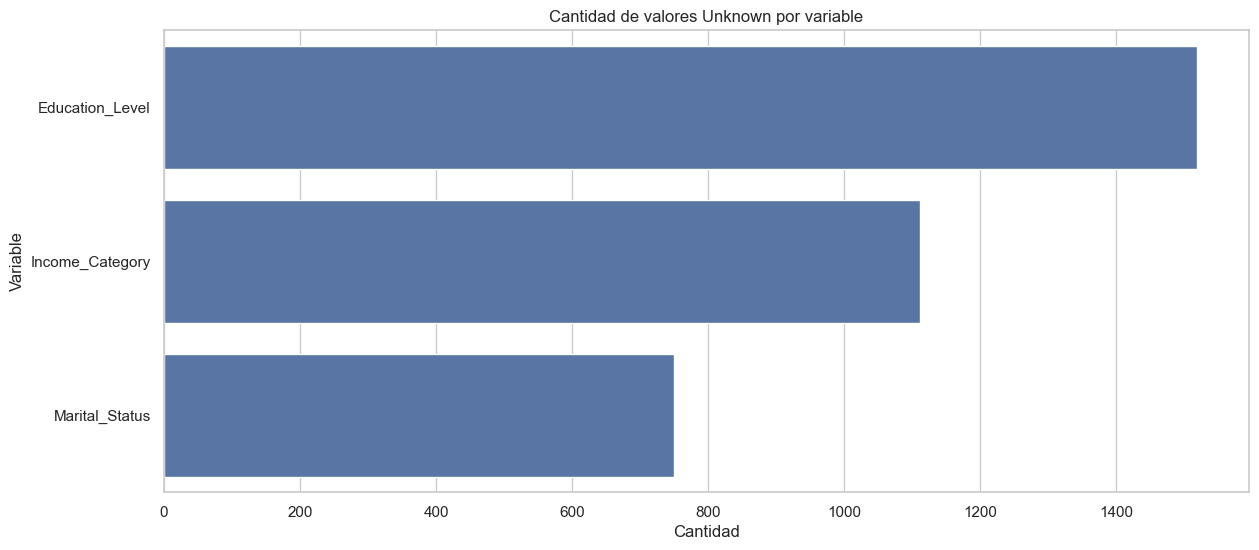

In [ ]:
sns.barplot(data=unknown_df, x='Cantidad', y='Variable')
plt.title('Cantidad de valores Unknown por variable')
plt.xlabel('Cantidad')
plt.ylabel('Variable')
plt.show()

Hay varios "Unknown" en el dataset. Significa que hay clientes que no completaron esa información. No los eliminamos. Podrían ser importantes: tal vez los clientes que se van son los que no completaron su perfil. Eso sería un patrón interesante.

## 4. Análisis de la variable objetivo

In [ ]:
df['Attrition_Flag'].value_counts(normalize=True)*100

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

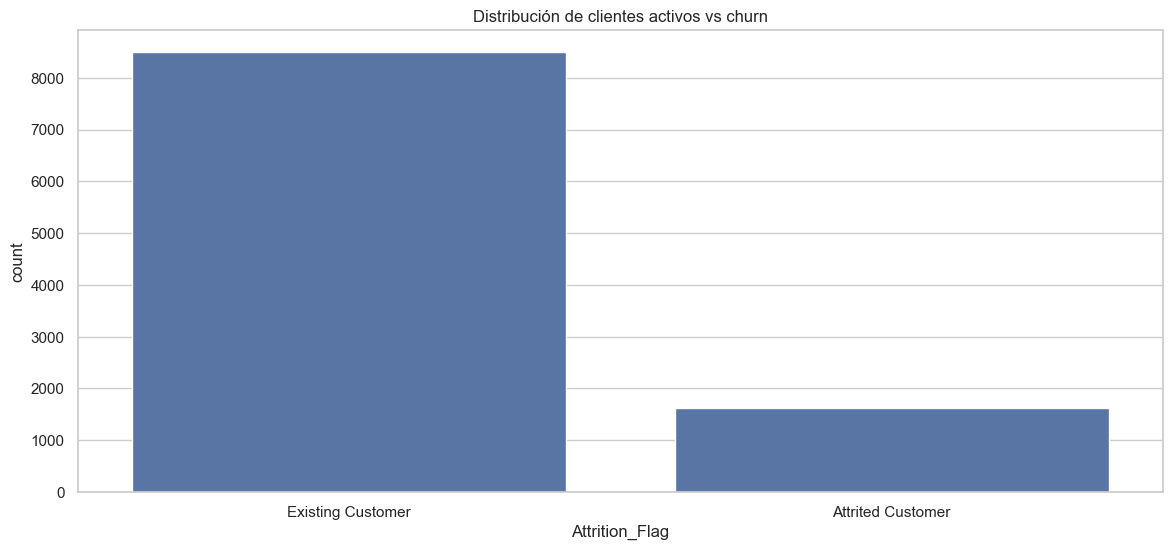

In [ ]:
sns.countplot(x='Attrition_Flag', data=df)
plt.title('Distribución de clientes activos vs churn')
plt.show()

El 16% se fue. El 84% se quedó. Es desbalanceado. Si hacemos un modelo que simplemente diga "todos se quedan", tenemos 84% de accuracy. Pero eso no sirve. Necesitamos que el modelo sea bueno en detectar quién se va, no en contar que la mayoría se queda. Por eso vamos a usar recall (¿cuántos de los que se fueron, el modelo detectó?) más que accuracy.